# Import statements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Data Exploration

Read the data

In [2]:
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Check for nulls

In [3]:
data.isna().any()

CustomerID                False
Gender                    False
Age                       False
Annual Income (k$)        False
Spending Score (1-100)    False
dtype: bool

Check for duplicates

In [4]:
data.duplicated().any()

np.False_

Descriptive statistics

In [5]:
data.shape
print(f"The data has {data.shape[0]} rows and {data.shape[1]} columns")

The data has 200 rows and 5 columns


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Distribution of income

Text(0.5, 1.0, 'Income Distribution')

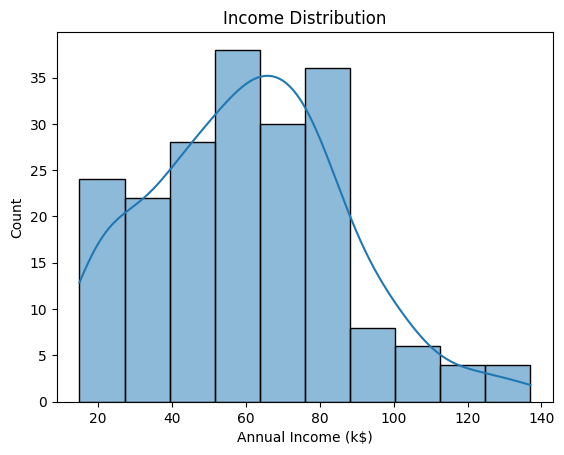

In [8]:
sns.histplot(data["Annual Income (k$)"], kde=True)
plt.title("Income Distribution")

Distribution of spending score

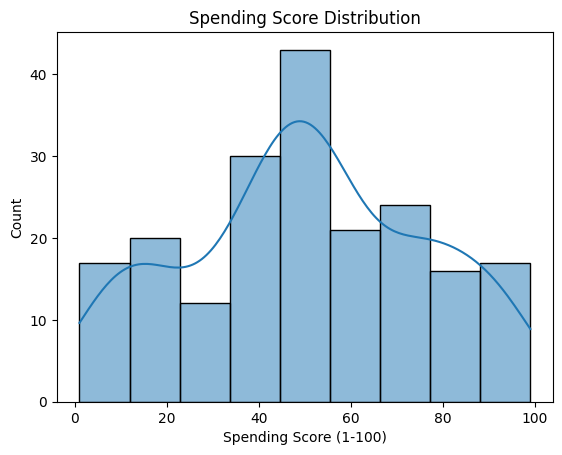

In [9]:
sns.histplot(data["Spending Score (1-100)"], kde=True)
plt.title("Spending Score Distribution")
plt.show()

Distribution of age

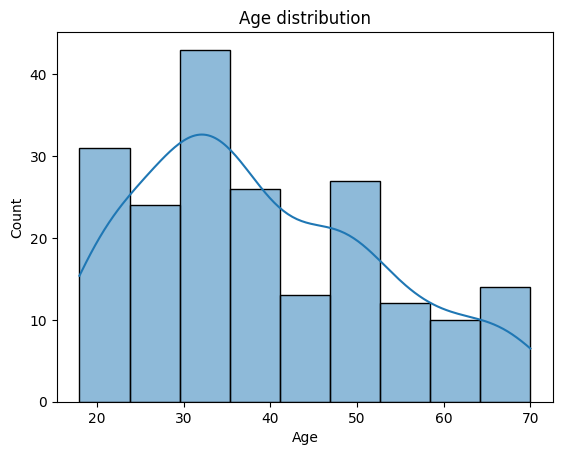

In [10]:
sns.histplot(data["Age"], kde=True)
plt.title("Age distribution")
plt.show()

Distribution of gender

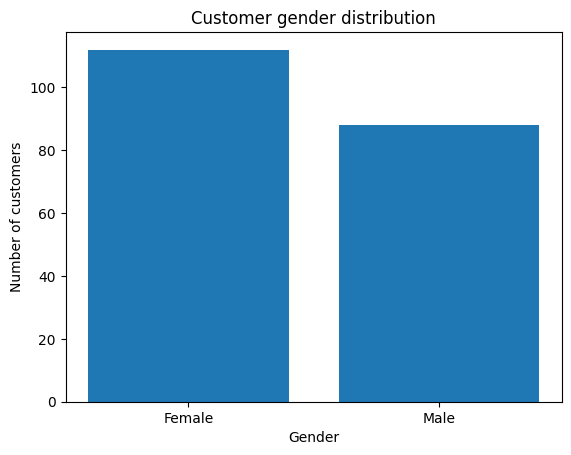

In [11]:
gender_counts = data["Gender"].value_counts()
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Customer gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of customers")
plt.show()

Relationship between income and spending score

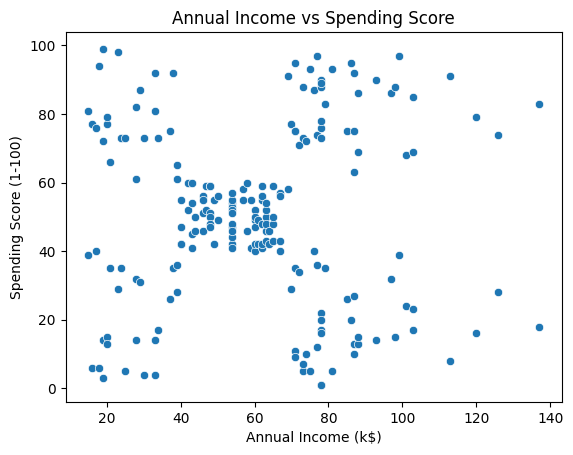

In [12]:
sns.scatterplot(data, x="Annual Income (k$)", y="Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

Relationship between age and spending score

Text(0, 0.5, 'Spending Score')

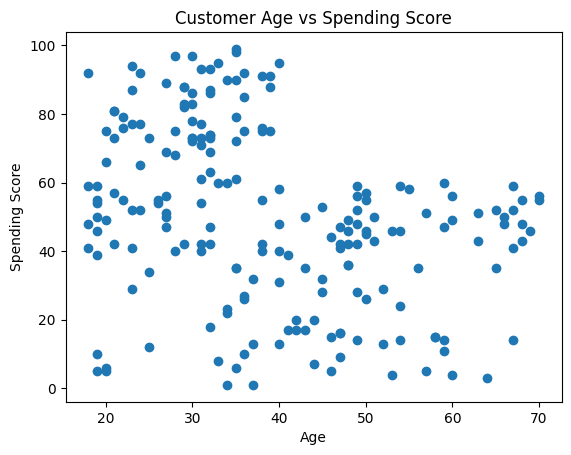

In [13]:
plt.scatter(data["Age"], data["Spending Score (1-100)"])
plt.title("Customer Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

Relationship between gender and spending score

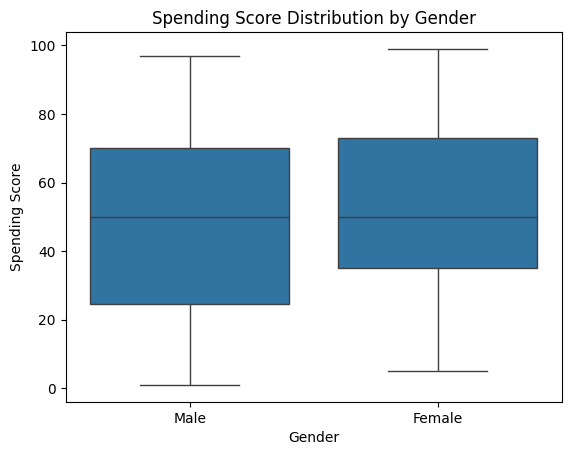

In [14]:
sns.boxplot(data, x="Gender", y="Spending Score (1-100)")
plt.title("Spending Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Spending Score")
plt.show()

# Clustering

Feature selection

In [15]:
feature_matrix = data[["Annual Income (k$)", "Spending Score (1-100)"]]
feature_matrix.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Scaling

In [16]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

The Elbow method

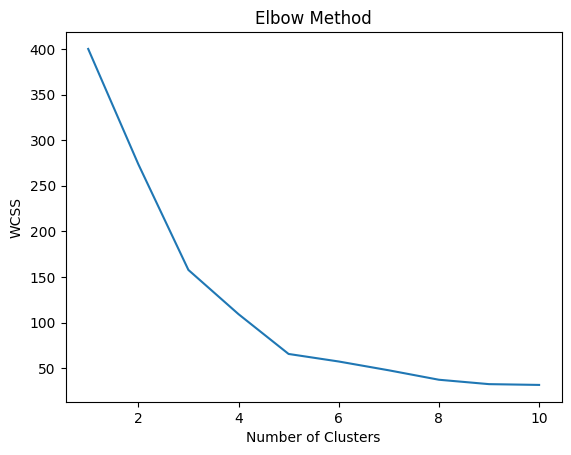

In [17]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [18]:
print("5 appears to be the optimal k")

5 appears to be the optimal k


The K-Means Model

In [19]:
# Create the K-Means model
kmeans = KMeans(n_clusters=5)
# Fit the model to the scaled data
kmeans.fit(scaled_features)
# Get the cluster labels
clusters = kmeans.labels_
clusters

array([0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 1,
       0, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 2, 1, 2, 3, 2, 3, 2,
       1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [20]:
# Adding the cluster labels to the dataset
feature_matrix["Cluster"] = clusters
feature_matrix

C:\Users\rosemary.njoroge\AppData\Local\Temp\ipykernel_25092\1191073836.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_matrix["Cluster"] = clusters


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,0
1,15,81,4
2,16,6,0
3,16,77,4
4,17,40,0
...,...,...,...
195,120,79,2
196,126,28,3
197,126,74,2
198,137,18,3


In [21]:
# View the cluster centers
kmeans.cluster_centers_

array([[-1.30751869, -1.13696536],
       [-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [ 1.05500302, -1.28443907],
       [-1.32954532,  1.13217788]])

Visualizing the clusters

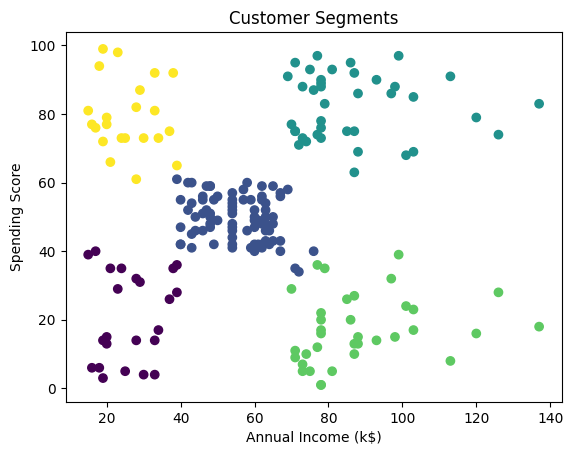

In [22]:
plt.scatter(feature_matrix["Annual Income (k$)"], feature_matrix["Spending Score (1-100)"], c=feature_matrix["Cluster"])
plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

# Interpreting the clusters

Profile table

In [23]:
cluster_profile = feature_matrix.groupby("Cluster").mean().round(1)
cluster_profile

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,26.3,20.9
1,55.3,49.5
2,86.5,82.1
3,88.2,17.1
4,25.7,79.4


Interpretation

<table>
    <tr>
        <th>Cluster</th>
        <th>Description</th>
        <th>Persona</th>
        <th>Suitable Marketing strategy</th>
    </tr>
    <tr>
        <td>0</td>
        <td>Medium income + Medium spending</td>
        <td>Average customers</td>
        <td>Loyalty programs and reward points</td>
    </tr>
    <tr>
        <td>1</td>
        <td>High income + Low spending</td>
        <td>Careful wealthy buyers</td>
        <td>Personalized recommendations</td>
    </tr>
    <tr>
        <td>2</td>
        <td>High income + High spending</td>
        <td>Luxury shoppers</td>
        <td>VIP services and exclusive experience</td>
    </tr>
    <tr>
        <td>3</td>
        <td>Low income + High spending</td>
        <td>Impulse buyers</td>
        <td>Limited time offers and trend promotions</td>
    </tr>
    <tr>
        <td>4</td>
        <td>Low income + Low spending</td>
        <td>Budget-conscious customers</td>
        <td>Discounts and clearance promotions</td>
    </tr>
</table>